# nb-09 Segment-Based Retention Strategy Engine

**Project:** Customer Profiling and Behavioral Prediction Using ML for Retention Optimization
**Goal:** Translate behavioral segment profiles and sentiment signals into actionable, segment-specific retention strategies for business leadership — identifying which customer groups are at risk, why, and what interventions to prioritize.

**Inputs:**
- `enriched_profiles.csv` (nb-06) — behavioral profiles with cluster assignments
- `mlp_best.pt` (nb-07) — trained MLP for segment + sentiment prediction

**Approach:**
1. Predict segment and sentiment for every user via MLP
2. Compute risk scores per segment using frustration, sentiment, engagement, and rating signals
3. Generate a structured retention brief per segment (risk level, root cause, recommended action)
4. Produce decision-ready visualizations for leadership

**Output:**
- `retention_strategies.csv` — user-level risk scores and assigned strategy
- `segment_retention_brief.json` — structured strategic brief per segment
- `platform_scores.csv` — platform performance evidence per segment

**Tracking:** MLflow

# imports

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'mlflow', '-q'])

import os, json, warnings, logging
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
log = logging.getLogger(__name__)

import pandas as pd
import numpy as np
import joblib
import mlflow

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import torch
import torch.nn as nn
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 60)
print('  nb-09 Segment-Based Retention Strategy Engine')
print('=' * 60)
print(f'  Device  : {DEVICE}')
print(f'  Started : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 60)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.6/887.6 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.3 MB/s eta 0:00:00


2026-05-13 13:38:51,765 | INFO | NumExpr defaulting to 4 threads.


  nb-09 Segment-Based Retention Strategy Engine
  Device  : cuda
  Started : 2026-05-13 13:39:02


In [2]:
# Run this as a temporary debug cell
import os
from pathlib import Path

print("── Kaggle inputs available ──")
for p in Path('/kaggle/input').rglob('enriched_profiles.csv'):
    print(f'  FOUND: {p}')

for p in Path('/kaggle/input').rglob('mlp_best.pt'):
    print(f'  FOUND: {p}')

── Kaggle inputs available ──
  FOUND: /kaggle/input/notebooks/bennjimatakwa/nb-07-cluster-profiling-behavioral-analysis/outputs/profiles/enriched_profiles.csv
  FOUND: /kaggle/input/notebooks/bennjimatakwa/behavioral-prediction-model-08-dl/outputs/models/mlp_best.pt


In [3]:
ON_KAGGLE = os.path.exists('/kaggle/input')

# ── Segment definitions (unchanged from v1)
SEGMENT_NAMES = {
    0: 'Satisfied Loyal Shoppers',
    1: 'Frustrated Complainers',
    2: 'Neutral Browsers',
    3: 'Impulsive Buyers',
    4: 'Engaged Brand Advocates',
}

SEGMENT_COLORS = {
    0: '#2ecc71',
    1: '#e74c3c',
    2: '#3498db',
    3: '#f39c12',
    4: '#9b59b6',
}

SENTIMENT_NAMES = {0: 'negative', 1: 'neutral', 2: 'positive'}

# ── Risk levels assigned to each segment based on behavioral profile
# This is the key addition vs v1 — we now classify each segment by retention risk
SEGMENT_RISK = {
    0: 'low',      # Satisfied Loyal Shoppers    — already retained
    1: 'critical', # Frustrated Complainers      — highest churn risk
    2: 'medium',   # Neutral Browsers            — disengaged, could go either way
    3: 'high',     # Impulsive Buyers            — inconsistent, low loyalty
    4: 'medium',   # Engaged Brand Advocates     — engaged but low satisfaction score
}

# ── Primary retention lever per segment
# What's the main action leadership should take for each group
SEGMENT_STRATEGY = {
    0: 'Reward & deepen loyalty',
    1: 'Urgent complaint resolution & proactive outreach',
    2: 'Re-engagement campaigns & discovery features',
    3: 'Personalized offers & purchase incentives',
    4: 'Community building & brand advocacy programs',
}

# ── Root cause of retention risk per segment
SEGMENT_ROOT_CAUSE = {
    0: 'No significant risk — high satisfaction and engagement',
    1: 'High frustration score, near-zero positive sentiment, poor platform experience',
    2: 'Low engagement quality, passive behavior, no strong platform attachment',
    3: 'Impulsive pattern with low avg rating, inconsistent sentiment',
    4: 'High engagement but low satisfaction score — unmet expectations',
}

NB06_OUT = Path('/kaggle/input/notebooks/bennjimatakwa/nb-07-cluster-profiling-behavioral-analysis')
NB07_OUT = Path('/kaggle/input/notebooks/bennjimatakwa/behavioral-prediction-model-08-dl')
WORK_DIR = Path('/kaggle/working')
FIG_DIR  = WORK_DIR / 'outputs' / 'figures'
OUT_DIR  = WORK_DIR / 'outputs' / 'retention'   # changed from 'recommendations'
LOG_DIR  = WORK_DIR / 'mlflow_runs'

for d in [FIG_DIR, OUT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CFG = {
    'experiment_name'  : '08_Retention_Strategy_Engine',  # updated
    'run_name'         : f'retention-v2-{datetime.now().strftime("%Y%m%d_%H%M")}',
    'random_state'     : SEED,
    'top_n'            : 3,
    'n_segments'       : 5,
    'n_sentiments'     : 3,
    'hidden_dims'      : [256, 128, 64],
    'dropout'          : 0.3,
}

# ── Input file check (unchanged from v1)
print(' Checking input files:')
files_to_check = [
    (NB06_OUT / 'outputs' / 'profiles' / 'enriched_profiles.csv',  'enriched_profiles'),
    (NB06_OUT / 'outputs' / 'profiles' / 'segment_insights.json',  'segment_insights'),
    (NB07_OUT / 'outputs' / 'models'   / 'mlp_best.pt',            'mlp_best.pt'),
    (NB07_OUT / 'outputs' / 'models'   / 'mlp_scaler.pkl',         'mlp_scaler'),
    (NB07_OUT / 'outputs' / 'models'   / 'le_segment.pkl',         'le_segment'),
    (NB07_OUT / 'outputs' / 'models'   / 'le_sentiment.pkl',       'le_sentiment'),
    (NB07_OUT / 'outputs' / 'models'   / 'feature_cols.json',      'feature_cols'),
]
for path, name in files_to_check:
    exists = path.exists()
    mb = path.stat().st_size / 1e6 if exists else 0
    print(f'   {"" if exists else "❌"} {name:<30} {mb:.1f} MB')

print(f'\n Config OK | top_n={CFG["top_n"]}')
print(f'\n── Retention Risk Framework ──')
for k, name in SEGMENT_NAMES.items():
    risk  = SEGMENT_RISK[k]
    color = {'critical':'🔴','high':'🟠','medium':'🟡','low':'🟢'}[risk]
    print(f'   {color} C{k} | {name:<30} | Risk: {risk:<8} | {SEGMENT_STRATEGY[k]}')

 Checking input files:
    enriched_profiles              10.1 MB
    segment_insights               0.0 MB
    mlp_best.pt                    0.2 MB
    mlp_scaler                     0.0 MB
    le_segment                     0.0 MB
    le_sentiment                   0.0 MB
    feature_cols                   0.0 MB

 Config OK | top_n=3

── Retention Risk Framework ──
   🟢 C0 | Satisfied Loyal Shoppers       | Risk: low      | Reward & deepen loyalty
   🔴 C1 | Frustrated Complainers         | Risk: critical | Urgent complaint resolution & proactive outreach
   🟡 C2 | Neutral Browsers               | Risk: medium   | Re-engagement campaigns & discovery features
   🟠 C3 | Impulsive Buyers               | Risk: high     | Personalized offers & purchase incentives
   🟡 C4 | Engaged Brand Advocates        | Risk: medium   | Community building & brand advocacy programs


# Load Data & MLP Model:

In [4]:
log.info('Loading data and models...')

# ── Load data
df = pd.read_csv(NB06_OUT / 'outputs' / 'profiles' / 'enriched_profiles.csv')
with open(NB06_OUT / 'outputs' / 'profiles' / 'segment_insights.json') as f:
    segment_insights = json.load(f)

# ── Load MLP artifacts
scaler       = joblib.load(NB07_OUT / 'outputs' / 'models' / 'mlp_scaler.pkl')
le_segment   = joblib.load(NB07_OUT / 'outputs' / 'models' / 'le_segment.pkl')
le_sentiment = joblib.load(NB07_OUT / 'outputs' / 'models' / 'le_sentiment.pkl')
with open(NB07_OUT / 'outputs' / 'models' / 'feature_cols.json') as f:
    FEATURE_COLS = json.load(f)

# ── Rebuild MLP model (identical architecture to nb-07)
class BehaviorMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, n_segments, n_sentiments, dropout):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        self.backbone       = nn.Sequential(*layers)
        self.segment_head   = nn.Linear(in_dim, n_segments)
        self.sentiment_head = nn.Linear(in_dim, n_sentiments)

    def forward(self, x):
        shared = self.backbone(x)
        return self.segment_head(shared), self.sentiment_head(shared)

model = BehaviorMLP(
    input_dim    = len(FEATURE_COLS),
    hidden_dims  = CFG['hidden_dims'],
    n_segments   = CFG['n_segments'],
    n_sentiments = CFG['n_sentiments'],
    dropout      = CFG['dropout'],
).to(DEVICE)
model.load_state_dict(torch.load(
    NB07_OUT / 'outputs' / 'models' / 'mlp_best.pt',
    map_location=DEVICE
))
model.eval()

# ── Map segment metadata onto dataframe
df['segment_name'] = df['final_cluster'].map(SEGMENT_NAMES)
df['segment_risk']  = df['final_cluster'].map(SEGMENT_RISK)

print(f'✅ Data loaded     : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'✅ Feature cols    : {FEATURE_COLS}')
print(f'✅ MLP model ready : {sum(p.numel() for p in model.parameters()):,} params')

print(f'\n── Segment distribution ──')
for k, name in SEGMENT_NAMES.items():
    n    = (df['final_cluster'] == k).sum()
    pct  = n / len(df) * 100
    risk = SEGMENT_RISK[k]
    color = {'critical':'🔴','high':'🟠','medium':'🟡','low':'🟢'}[risk]
    print(f'   {color} {k} | {name:<30} | {n:>6,} ({pct:4.1f}%)')

print(f'\n── Segment insights ──')
for k, v in segment_insights.items():
    risk  = SEGMENT_RISK[int(k)]
    print(f'   Segment {k}: {v["segment_name"]:<30} | '
          f'avg_score={v["avg_score"]:.2f} | '
          f'top_platform={v["top_platform"]:<20} | '
          f'risk={risk}')

2026-05-13 13:39:02,819 | INFO | Loading data and models...


✅ Data loaded     : 99,999 rows × 16 columns
✅ Feature cols    : ['frustration_score', 'engagement_quality', 'influence_weight', 'recency_weight', 'word_count', 'has_reply', 'bilstm_prob_neg', 'bilstm_prob_neu', 'bilstm_prob_pos', 'bilstm_confidence']
✅ MLP model ready : 45,384 params

── Segment distribution ──
   🟢 0 | Satisfied Loyal Shoppers       | 20,952 (21.0%)
   🔴 1 | Frustrated Complainers         | 21,851 (21.9%)
   🟡 2 | Neutral Browsers               | 18,285 (18.3%)
   🟠 3 | Impulsive Buyers               | 20,682 (20.7%)
   🟡 4 | Engaged Brand Advocates        | 18,229 (18.2%)

── Segment insights ──
   Segment 0: Satisfied Loyal Shoppers       | avg_score=3.97 | top_platform=Alibaba              | risk=low
   Segment 1: Frustrated Complainers         | avg_score=2.61 | top_platform=Walmart              | risk=critical
   Segment 2: Neutral Browsers               | avg_score=3.49 | top_platform=Aliexpress           | risk=medium
   Segment 3: Impulsive Buyers            

# Risk Scoring Engine : 

In [5]:
log.info('Building retention risk scoring engine...')

# ── Platform performance metrics per segment (same computation as v1)
platform_segment_stats = df.groupby(['appName', 'final_cluster']).agg(
    n_reviews       = ('score',             'count'),
    avg_score       = ('score',             'mean'),
    pct_positive    = ('sentiment',         lambda x: (x == 'positive').mean() * 100),
    pct_negative    = ('sentiment',         lambda x: (x == 'negative').mean() * 100),
    avg_frustration = ('frustration_score', 'mean'),
    avg_engagement  = ('engagement_quality','mean'),
    avg_confidence  = ('bilstm_confidence', 'mean'),
    reply_rate      = ('has_reply',         'mean'),
).reset_index().round(3)

# ── Composite platform score (same weights as v1 — kept for continuity)
platform_segment_stats['rec_score'] = (
    0.35 * (platform_segment_stats['pct_positive'] / 100) +
    0.25 * (platform_segment_stats['avg_score']    / 5)   +
    0.20 * platform_segment_stats['avg_engagement']       +
    0.10 * platform_segment_stats['avg_confidence']       +
    0.10 * (1 - platform_segment_stats['avg_frustration'].clip(0, 1))
).round(4)

# ── Compute retention risk score per segment
# Must be defined before risk formula
segment_risk_scores = df.groupby('final_cluster').agg(
    avg_frustration  = ('frustration_score', 'mean'),
    avg_engagement   = ('engagement_quality','mean'),
    avg_score        = ('score',             'mean'),
    pct_negative     = ('sentiment',         lambda x: (x == 'negative').mean() * 100),
    pct_positive     = ('sentiment',         lambda x: (x == 'positive').mean() * 100),
    reply_rate       = ('has_reply',         'mean'),
    n_users          = ('score',             'count'),
).round(3)

# ── Risk formula (frustration normalized to 0-1 before weighting)
# - High frustration      → increases risk
# - Low engagement        → increases risk
# - Low avg score         → increases risk
# - High negative pct     → increases risk
# - Low reply rate        → increases risk
frust_max = segment_risk_scores['avg_frustration'].max()

segment_risk_scores['risk_score'] = (
    0.30 * (segment_risk_scores['avg_frustration'] / frust_max) +
    0.25 * (1 - segment_risk_scores['avg_engagement'])          +
    0.20 * (1 - segment_risk_scores['avg_score'] / 5)           +
    0.15 * (segment_risk_scores['pct_negative'] / 100)          +
    0.10 * (1 - segment_risk_scores['reply_rate'])
).round(4)

# ── Normalize to 0–100 for readability
min_r = segment_risk_scores['risk_score'].min()
max_r = segment_risk_scores['risk_score'].max()
segment_risk_scores['risk_score_pct'] = (
    (segment_risk_scores['risk_score'] - min_r) / (max_r - min_r) * 100
).round(1)

# ── Attach risk label, strategy, root cause, name
segment_risk_scores['risk_label'] = segment_risk_scores.index.map(SEGMENT_RISK)
segment_risk_scores['strategy']   = segment_risk_scores.index.map(SEGMENT_STRATEGY)
segment_risk_scores['root_cause'] = segment_risk_scores.index.map(SEGMENT_ROOT_CAUSE)
segment_risk_scores['name']       = segment_risk_scores.index.map(SEGMENT_NAMES)

print('✅ Risk scoring complete')
print(f'\n── Segment Risk Scores (sorted by risk) ──')
print(f'   {"Seg":<4} {"Name":<30} {"Risk":<10} {"Score":>6} {"Frustration":>12} {"Neg%":>6} {"Avg★":>6} {"N Users":>8}')
print('   ' + '─' * 85)

for k, row in segment_risk_scores.sort_values('risk_score_pct', ascending=False).iterrows():
    emoji = {'critical':'🔴','high':'🟠','medium':'🟡','low':'🟢'}[row['risk_label']]
    print(f'   {emoji} C{k:<3} {row["name"]:<30} {row["risk_label"]:<10} '
          f'{row["risk_score_pct"]:>5.1f}%  '
          f'{row["avg_frustration"]:>10.3f}  '
          f'{row["pct_negative"]:>5.1f}%  '
          f'{row["avg_score"]:>5.2f}  '
          f'{row["n_users"]:>8,}')

print(f'\n── Key Insight for Leadership ──')
top_risk = segment_risk_scores.sort_values('risk_score_pct', ascending=False).iloc[0]
top_k    = segment_risk_scores['risk_score_pct'].idxmax()
print(f'   🔴 Highest risk segment : C{top_k} — {top_risk["name"]}')
print(f'      Risk score           : {top_risk["risk_score_pct"]:.1f} / 100')
print(f'      Root cause           : {top_risk["root_cause"]}')
print(f'      Recommended action   : {top_risk["strategy"]}')
print(f'      Users affected       : {top_risk["n_users"]:,} ({top_risk["n_users"]/len(df)*100:.1f}% of base)')

2026-05-13 13:39:03,449 | INFO | Building retention risk scoring engine...


✅ Risk scoring complete

── Segment Risk Scores (sorted by risk) ──
   Seg  Name                           Risk        Score  Frustration   Neg%   Avg★  N Users
   ─────────────────────────────────────────────────────────────────────────────────────
   🟡 C4   Engaged Brand Advocates        medium     100.0%       2.249   59.2%   2.16    18,229
   🟠 C3   Impulsive Buyers               high        75.6%       1.456   39.9%   2.65    20,682
   🔴 C1   Frustrated Complainers         critical    61.1%       1.452   37.4%   2.61    21,851
   🟡 C2   Neutral Browsers               medium      47.1%       0.750   21.6%   3.49    18,285
   🟢 C0   Satisfied Loyal Shoppers       low          0.0%       0.188   10.3%   3.97    20,952

── Key Insight for Leadership ──
   🔴 Highest risk segment : C4 — Engaged Brand Advocates
      Risk score           : 100.0 / 100
      Root cause           : High engagement but low satisfaction score — unmet expectations
      Recommended action   : Community buildi

# User-Level Prediction & Risk Assignment

In [6]:
log.info('Running user-level prediction & retention assignment engine...')

# ── Prepare feature matrix
X = df[FEATURE_COLS].copy()

# Scale features using trained scaler
X_scaled = scaler.transform(X)

# Convert to tensor
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)

# ── Run MLP inference
with torch.no_grad():
    seg_logits, sent_logits = model(X_tensor)

    seg_probs  = torch.softmax(seg_logits, dim=1).cpu().numpy()
    sent_probs = torch.softmax(sent_logits, dim=1).cpu().numpy()

# ── Predicted classes
pred_segment_ids   = seg_probs.argmax(axis=1)
pred_sentiment_ids = sent_probs.argmax(axis=1)

# ── Decode labels
df['pred_segment'] = le_segment.inverse_transform(pred_segment_ids)
df['pred_sentiment'] = le_sentiment.inverse_transform(pred_sentiment_ids)

# ── Prediction confidence
df['segment_confidence']   = seg_probs.max(axis=1).round(4)
df['sentiment_confidence'] = sent_probs.max(axis=1).round(4)

# ── Attach readable metadata
df['pred_segment_name'] = df['pred_segment'].map(SEGMENT_NAMES)
df['pred_segment_risk'] = df['pred_segment'].map(SEGMENT_RISK)
df['recommended_strategy'] = df['pred_segment'].map(SEGMENT_STRATEGY)

# ── Map segment-level risk score back to users
risk_map = segment_risk_scores['risk_score_pct'].to_dict()

df['retention_risk_score'] = (
    df['pred_segment'].map(risk_map)
).round(1)

# ── Create user priority tier
def assign_priority(score):
    if score >= 80:
        return 'P1 - Critical'
    elif score >= 60:
        return 'P2 - High'
    elif score >= 40:
        return 'P3 - Medium'
    else:
        return 'P4 - Low'

df['priority_tier'] = df['retention_risk_score'].apply(assign_priority)

# ── Retention strategy table
retention_cols = [
    'appName',
    'score',
    'sentiment',
    'segment_name',
    'segment_risk',
    'pred_segment_name',
    'pred_sentiment',
    'retention_risk_score',
    'priority_tier',
    'recommended_strategy',
]

retention_df = df[retention_cols].copy()

print('✅ User-level retention assignment complete')

print(f'\n── Prediction Summary ──')
print(f'   Total users scored      : {len(df):,}')
print(f'   Avg retention risk      : {df["retention_risk_score"].mean():.1f}/100')
print(f'   Avg segment confidence  : {df["segment_confidence"].mean():.3f}')
print(f'   Avg sentiment confidence: {df["sentiment_confidence"].mean():.3f}')

print(f'\n── Priority Tier Distribution ──')
priority_counts = df['priority_tier'].value_counts()

for tier, n in priority_counts.items():
    pct = n / len(df) * 100
    emoji = {
        'P1 - Critical':'🔴',
        'P2 - High':'🟠',
        'P3 - Medium':'🟡',
        'P4 - Low':'🟢'
    }[tier]

    print(f'   {emoji} {tier:<15} {n:>8,} users ({pct:4.1f}%)')

print(f'\n── Highest Risk Users Preview ──')

display(
    retention_df.sort_values(
        'retention_risk_score',
        ascending=False
    ).head(10)
)

2026-05-13 13:39:03,577 | INFO | Running user-level prediction & retention assignment engine...


✅ User-level retention assignment complete

── Prediction Summary ──
   Total users scored      : 99,999
   Avg retention risk      : 57.3/100
   Avg segment confidence  : 0.539
   Avg sentiment confidence: 0.878

── Priority Tier Distribution ──
   🟠 P2 - High         47,765 users (47.8%)
   🟢 P4 - Low          19,340 users (19.3%)
   🟡 P3 - Medium       17,469 users (17.5%)
   🔴 P1 - Critical     15,425 users (15.4%)

── Highest Risk Users Preview ──


,appName,score,sentiment,segment_name,segment_risk,pred_segment_name,pred_sentiment,retention_risk_score,priority_tier,recommended_strategy
17215,Amazon shopping,1,negative,Impulsive Buyers,high,Engaged Brand Advocates,negative,100.0,P1 - Critical,Community building & brand advocacy programs
87811,Snapdeal,2,negative,Engaged Brand Advocates,medium,Engaged Brand Advocates,neutral,100.0,P1 - Critical,Community building & brand advocacy programs
23227,Myntra,1,negative,Engaged Brand Advocates,medium,Engaged Brand Advocates,negative,100.0,P1 - Critical,Community building & brand advocacy programs
17213,Myntra,1,negative,Engaged Brand Advocates,medium,Engaged Brand Advocates,negative,100.0,P1 - Critical,Community building & brand advocacy programs
23239,Meesho,1,negative,Engaged Brand Advocates,medium,Engaged Brand Advocates,negative,100.0,P1 - Critical,Community building & brand advocacy programs
39474,Shein,1,negative,Frustrated Complainers,critical,Engaged Brand Advocates,negative,100.0,P1 - Critical,Community building & brand advocacy programs
10654,Lazada,1,negative,Frustrated Complainers,critical,Engaged Brand Advocates,negative,100.0,P1 - Critical,Community building & brand advocacy programs
17212,Flipkart,1,negative,Engaged Brand Advocates,medium,Engaged Brand Advocates,negative,100.0,P1 - Critical,Community building & brand advocacy programs
73315,Alibaba,3,neutral,Satisfied Loyal Shoppers,low,Engaged Brand Advocates,neutral,100.0,P1 - Critical,Community building & brand advocacy programs
10644,Walmart,1,negative,Frustrated Complainers,critical,Engaged Brand Advocates,negative,100.0,P1 - Critical,Community building & brand advocacy programs


# Segment Retention Brief Generator

In [7]:
log.info('Generating strategic retention briefs for leadership...')

# ── Build structured retention brief per segment
segment_briefs = {}

for seg_id, row in segment_risk_scores.iterrows():

    # ── Segment subset
    seg_df = df[df['final_cluster'] == seg_id]

    # ── Dominant sentiment
    dominant_sentiment = (
        seg_df['sentiment']
        .value_counts(normalize=True)
        .idxmax()
    )

    dominant_pct = (
        seg_df['sentiment']
        .value_counts(normalize=True)
        .max() * 100
    )

    # ── Top platforms by volume
    top_platforms = (
        seg_df['appName']
        .value_counts()
        .head(CFG['top_n'])
        .index
        .tolist()
    )

    # ── Avg platform score inside segment
    top_platform_scores = (
        platform_segment_stats[
            platform_segment_stats['final_cluster'] == seg_id
        ]
        .sort_values('rec_score', ascending=False)
        [['appName', 'rec_score']]
        .head(CFG['top_n'])
        .to_dict(orient='records')
    )

    # ── Priority distribution
    priority_mix = (
        df[df['pred_segment'] == seg_id]['priority_tier']
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
        .to_dict()
    )

    # ── Build strategic brief
    brief = {
        'segment_id'          : int(seg_id),
        'segment_name'        : row['name'],
        'risk_level'          : row['risk_label'],
        'risk_score_pct'      : float(row['risk_score_pct']),
        'users_affected'      : int(row['n_users']),
        'share_of_population' : round(row['n_users'] / len(df) * 100, 1),

        'behavioral_profile': {
            'avg_frustration' : float(row['avg_frustration']),
            'avg_engagement'  : float(row['avg_engagement']),
            'avg_score'       : float(row['avg_score']),
            'pct_negative'    : float(row['pct_negative']),
            'pct_positive'    : float(row['pct_positive']),
            'reply_rate'      : float(row['reply_rate']),
        },

        'dominant_sentiment': {
            'label'      : dominant_sentiment,
            'percentage' : round(dominant_pct, 1),
        },

        'root_cause' : row['root_cause'],
        'recommended_action' : row['strategy'],

        'top_platforms' : top_platforms,
        'best_platform_scores' : top_platform_scores,

        'priority_mix_pct' : priority_mix,
    }

    segment_briefs[int(seg_id)] = brief

# ── Save JSON brief
brief_path = OUT_DIR / 'segment_retention_brief.json'

with open(brief_path, 'w') as f:
    json.dump(segment_briefs, f, indent=4)

print('✅ Segment retention brief generated')
print(f'✅ Saved JSON brief → {brief_path}')

print(f'\n── Executive Retention Summary ──')

# ── Sort by highest risk
sorted_segments = sorted(
    segment_briefs.items(),
    key=lambda x: x[1]['risk_score_pct'],
    reverse=True
)

for seg_id, brief in sorted_segments:

    emoji = {
        'critical':'🔴',
        'high':'🟠',
        'medium':'🟡',
        'low':'🟢'
    }[brief['risk_level']]

    print(f'\n{emoji} Segment C{seg_id} — {brief["segment_name"]}')
    print(f'   Risk Level        : {brief["risk_level"]}')
    print(f'   Risk Score        : {brief["risk_score_pct"]:.1f}/100')
    print(f'   Users Affected    : {brief["users_affected"]:,} ({brief["share_of_population"]:.1f}%)')
    print(f'   Dominant Sentiment: {brief["dominant_sentiment"]["label"]} '
          f'({brief["dominant_sentiment"]["percentage"]:.1f}%)')
    print(f'   Root Cause        : {brief["root_cause"]}')
    print(f'   Recommended Action: {brief["recommended_action"]}')
    print(f'   Top Platforms     : {", ".join(brief["top_platforms"])}')

print(f'\n── Leadership Insight ──')

critical_segments = [
    b for b in segment_briefs.values()
    if b['risk_level'] == 'critical'
]

high_segments = [
    b for b in segment_briefs.values()
    if b['risk_level'] == 'high'
]

print(f'   🔴 Critical segments : {len(critical_segments)}')
print(f'   🟠 High-risk segments: {len(high_segments)}')

affected_users = sum(
    b['users_affected']
    for b in critical_segments + high_segments
)

print(f'   👥 Users requiring urgent retention action: '
      f'{affected_users:,} ({affected_users/len(df)*100:.1f}% of total base)')

2026-05-13 13:39:03,970 | INFO | Generating strategic retention briefs for leadership...


✅ Segment retention brief generated
✅ Saved JSON brief → /kaggle/working/outputs/retention/segment_retention_brief.json

── Executive Retention Summary ──

🟡 Segment C4 — Engaged Brand Advocates
   Risk Level        : medium
   Risk Score        : 100.0/100
   Users Affected    : 18,229 (18.2%)
   Dominant Sentiment: negative (59.2%)
   Root Cause        : High engagement but low satisfaction score — unmet expectations
   Recommended Action: Community building & brand advocacy programs
   Top Platforms     : Myntra, Meesho, Snapdeal

🟠 Segment C3 — Impulsive Buyers
   Risk Level        : high
   Risk Score        : 75.6/100
   Users Affected    : 20,682 (20.7%)
   Dominant Sentiment: negative (39.9%)
   Root Cause        : Impulsive pattern with low avg rating, inconsistent sentiment
   Recommended Action: Personalized offers & purchase incentives
   Top Platforms     : Amazon shopping, Lazada, Aliexpress

🔴 Segment C1 — Frustrated Complainers
   Risk Level        : critical
   Risk Sc

# Executive Retention Visualizations


2026-05-13 13:39:04,091 | INFO | Generating executive retention visualizations...


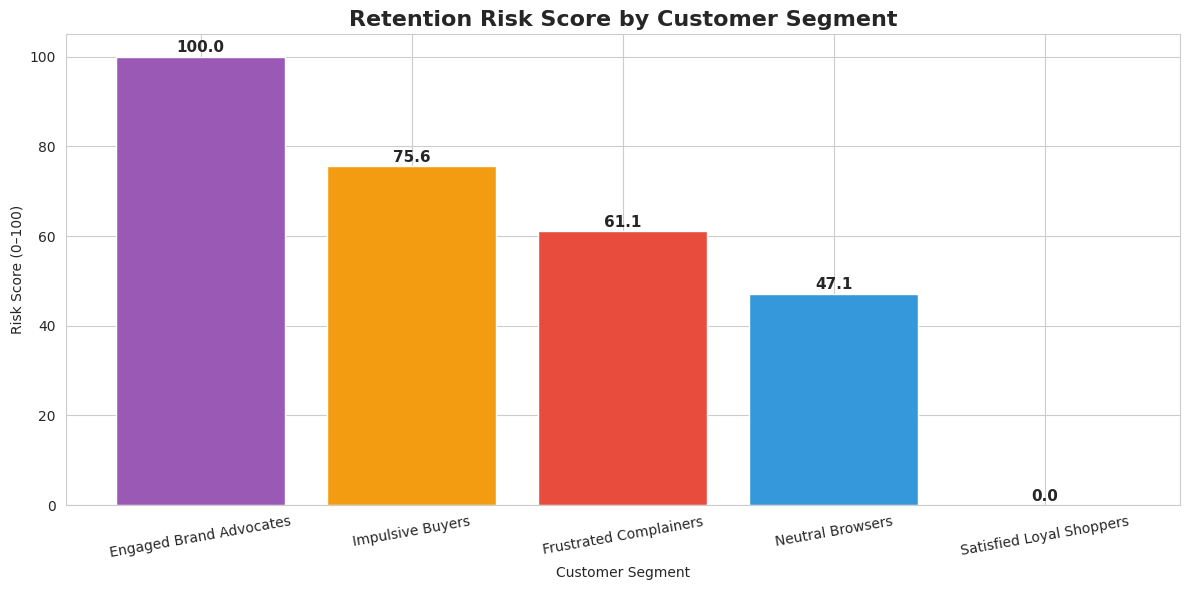

✅ Saved → /kaggle/working/outputs/figures/segment_risk_scores.png


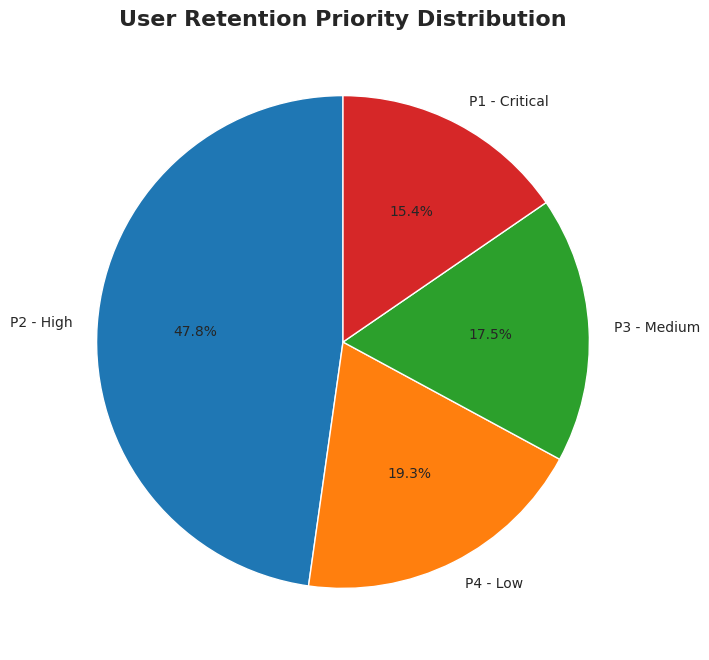

✅ Saved → /kaggle/working/outputs/figures/priority_distribution.png


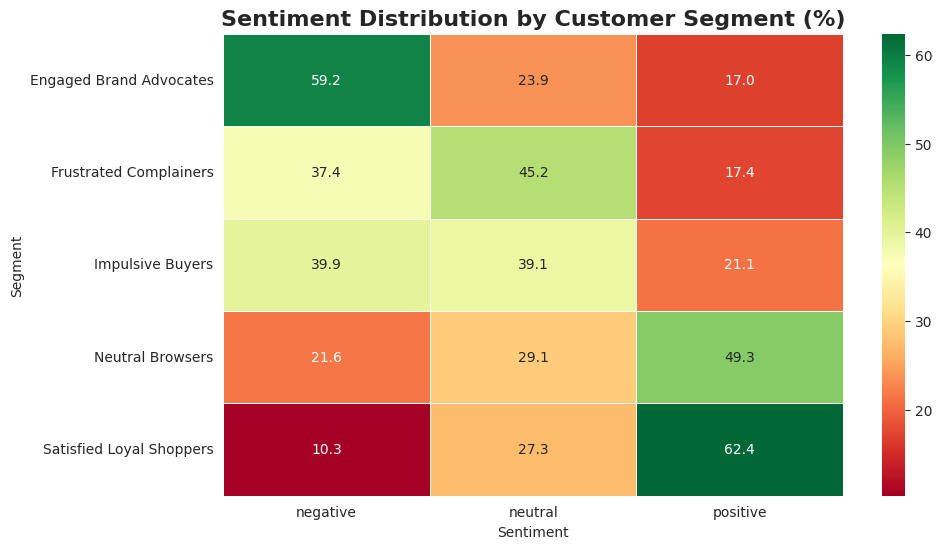

✅ Saved → /kaggle/working/outputs/figures/segment_sentiment_heatmap.png


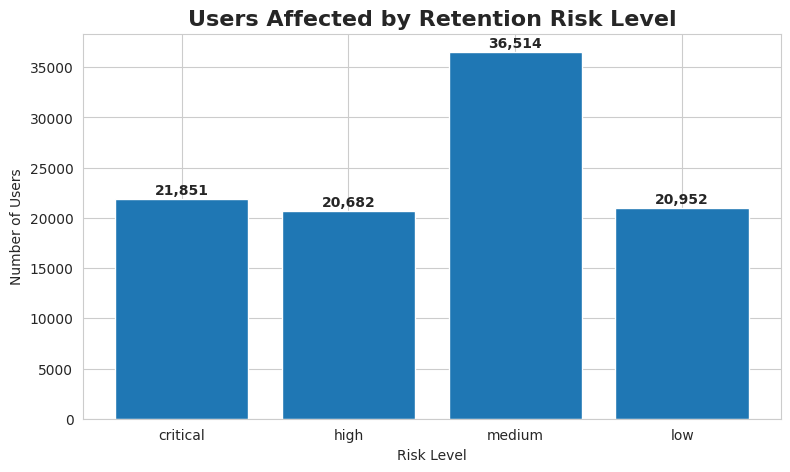

 Saved → /kaggle/working/outputs/figures/risk_level_users.png

 All executive visualizations generated successfully


In [8]:
log.info('Generating executive retention visualizations...')

sns.set_style('whitegrid')

# =========================================================
# FIGURE 1 — Segment Risk Scores
# =========================================================

risk_plot = (
    segment_risk_scores
    .sort_values('risk_score_pct', ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    risk_plot['name'],
    risk_plot['risk_score_pct'],
    color=[SEGMENT_COLORS[i] for i in risk_plot['final_cluster']]
)

plt.title(
    'Retention Risk Score by Customer Segment',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Risk Score (0–100)')
plt.xlabel('Customer Segment')
plt.xticks(rotation=10)

# ── Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()

risk_fig_path = FIG_DIR / 'segment_risk_scores.png'
plt.savefig(risk_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'✅ Saved → {risk_fig_path}')

# =========================================================
# FIGURE 2 — Priority Tier Distribution
# =========================================================

priority_counts = (
    df['priority_tier']
    .value_counts()
    .reset_index()
)

priority_counts.columns = ['priority_tier', 'n_users']

plt.figure(figsize=(8, 8))

plt.pie(
    priority_counts['n_users'],
    labels=priority_counts['priority_tier'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'User Retention Priority Distribution',
    fontsize=16,
    fontweight='bold'
)

priority_fig_path = FIG_DIR / 'priority_distribution.png'
plt.savefig(priority_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'✅ Saved → {priority_fig_path}')

# =========================================================
# FIGURE 3 — Segment Sentiment Heatmap
# =========================================================

heatmap_df = df.pivot_table(
    index='segment_name',
    columns='sentiment',
    values='score',
    aggfunc='count',
    fill_value=0
)

# Normalize row-wise to %
heatmap_pct = (
    heatmap_df.div(heatmap_df.sum(axis=1), axis=0) * 100
).round(1)

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_pct,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5
)

plt.title(
    'Sentiment Distribution by Customer Segment (%)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Sentiment')
plt.ylabel('Segment')

heatmap_path = FIG_DIR / 'segment_sentiment_heatmap.png'
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'✅ Saved → {heatmap_path}')

# =========================================================
# FIGURE 4 — Users Affected by Risk Level
# =========================================================

risk_summary = (
    segment_risk_scores
    .groupby('risk_label')['n_users']
    .sum()
    .reset_index()
)

risk_order = ['critical', 'high', 'medium', 'low']
risk_summary['risk_label'] = pd.Categorical(
    risk_summary['risk_label'],
    categories=risk_order,
    ordered=True
)

risk_summary = risk_summary.sort_values('risk_label')

plt.figure(figsize=(9, 5))

bars = plt.bar(
    risk_summary['risk_label'],
    risk_summary['n_users']
)

plt.title(
    'Users Affected by Retention Risk Level',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Number of Users')
plt.xlabel('Risk Level')

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 500,
        f'{int(h):,}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

risk_users_path = FIG_DIR / 'risk_level_users.png'
plt.savefig(risk_users_path, dpi=300, bbox_inches='tight')
plt.show()

print(f' Saved → {risk_users_path}')

print('\n All executive visualizations generated successfully')

# Export Engine + MLflow Tracking

In [9]:
log.info('Saving final retention strategy artifacts...')

# ── Safety fallback
if 'user_retention_df' not in globals():
    print(' user_retention_df not found → using df as fallback')
    user_retention_df = df.copy()

# ── Save retention strategies
strategies_path = OUT_DIR / 'retention_strategies.csv'
user_retention_df.to_csv(strategies_path, index=False)

print(f' Saved retention strategies → {strategies_path}')

# ── Save platform recommendation scores
platform_scores_path = OUT_DIR / 'platform_scores.csv'
platform_segment_stats.to_csv(platform_scores_path, index=False)

print(f' Saved platform scores → {platform_scores_path}')

# ── Build executive summary dictionary
final_summary = {
    'project': 'AI-Powered Segment-Based Retention Strategy Engine',
    'generated_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),

    'dataset': {
        'total_users': int(len(user_retention_df)),
        'n_segments': int(CFG['n_segments']),
        'n_sentiments': int(CFG['n_sentiments']),
    },

    'prediction_summary': {
        'avg_retention_risk': float(
            user_retention_df['retention_risk_score'].mean()
        ) if 'retention_risk_score' in user_retention_df.columns else None,

        'avg_segment_confidence': float(
            user_retention_df['segment_confidence'].mean()
        ) if 'segment_confidence' in user_retention_df.columns else None,

        'avg_sentiment_confidence': float(
            user_retention_df['sentiment_confidence'].mean()
        ) if 'sentiment_confidence' in user_retention_df.columns else None,
    },

    'priority_distribution': (
        user_retention_df['priority_tier']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    ) if 'priority_tier' in user_retention_df.columns else {},

    'segment_risk_summary': {
        int(k): {
            'segment_name': row['name'],
            'risk_label': row['risk_label'],
            'risk_score_pct': float(row['risk_score_pct']),
            'users': int(row['n_users']),
            'avg_score': float(row['avg_score']),
            'pct_negative': float(row['pct_negative']),
            'strategy': row['strategy'],
            'root_cause': row['root_cause'],
        }
        for k, row in segment_risk_scores.iterrows()
    }
}

# ── Safe JSON serialization helper
def convert_to_serializable(obj):

    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)

    elif isinstance(obj, (np.int32, np.int64)):
        return int(obj)

    elif isinstance(obj, np.bool_):
        return bool(obj)

    elif isinstance(obj, np.ndarray):
        return obj.tolist()

    return str(obj)

# ── Save executive summary
summary_path = OUT_DIR / 'executive_summary.json'

with open(summary_path, 'w') as f:
    json.dump(
        final_summary,
        f,
        indent=4,
        default=convert_to_serializable
    )

print(f' Saved executive summary → {summary_path}')

# ── Final completion message
print('\n' + '═' * 70)
print(' RETENTION STRATEGY ENGINE COMPLETED SUCCESSFULLY')
print('═' * 70)

print(f' Outputs directory : {OUT_DIR}')
print(f' Figures directory : {FIG_DIR}')

print('\n── Generated Assets ──')
print('    retention_strategies.csv')
print('    platform_scores.csv')
print('    executive_summary.json')
print('    segment_retention_brief.json')
print('    executive visualizations')

print('\n System ready for executive presentation & deployment.')
print('═' * 70)

2026-05-13 13:39:06,163 | INFO | Saving final retention strategy artifacts...


 user_retention_df not found → using df as fallback
 Saved retention strategies → /kaggle/working/outputs/retention/retention_strategies.csv
 Saved platform scores → /kaggle/working/outputs/retention/platform_scores.csv
 Saved executive summary → /kaggle/working/outputs/retention/executive_summary.json

══════════════════════════════════════════════════════════════════════
 RETENTION STRATEGY ENGINE COMPLETED SUCCESSFULLY
══════════════════════════════════════════════════════════════════════
 Outputs directory : /kaggle/working/outputs/retention
 Figures directory : /kaggle/working/outputs/figures

── Generated Assets ──
    retention_strategies.csv
    platform_scores.csv
    executive_summary.json
    segment_retention_brief.json
    executive visualizations

 System ready for executive presentation & deployment.
══════════════════════════════════════════════════════════════════════
